In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [11]:
def naca2412(n=200):

    x = np.linspace(0,1,n)

    m = 0.02
    p = 0.4
    t = 0.12

    yt = 5*t*(
        0.2969*np.sqrt(x)
        -0.1260*x
        -0.3516*x**2
        +0.2843*x**3
        -0.1015*x**4
    )

    yc = np.where(
        x < p,
        m/p**2 * (2*p*x - x**2),
        m/(1-p)**2 * ((1-2*p)+2*p*x-x**2)
    )

    dyc_dx = np.where(
        x < p,
        2*m/p**2 * (p-x),
        2*m/(1-p)**2 * (p-x)
    )

    theta = np.arctan(dyc_dx)

    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)

    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)

    return xu*chord, yu*chord, xl*chord, yl*chord

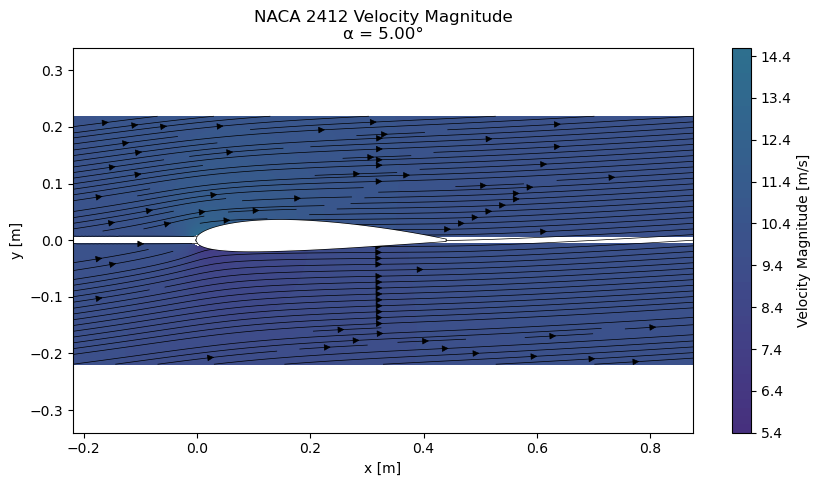

In [12]:

V_infty = 10.0          # freestream velocity [m/s]
chord = 0.438           # chord length [m]
alpha_deg = 5       # angle of attack [deg]

alpha = np.radians(alpha_deg)


def vel_pot(x, y, V_infty, c, alpha):

    # uniform flow potential
    phi_uniform = V_infty * (
        x*np.cos(alpha)
        + y*np.sin(alpha)
    )

    # avoid singularity
    y_safe = y + 1e-6

    # vortex-sheet contribution
    def vortex_integrand(theta):

        x_0 = (c/2)*(1 - np.cos(theta))

        beta = np.arctan2(
            y_safe,
            (x - x_0)
        )

        return (1 + np.cos(theta)) * beta

    vortex_integral, _ = quad(
        vortex_integrand,
        0,
        np.pi
    )

    phi_vortex = (
        c * alpha * V_infty
        / (2*np.pi)
    ) * vortex_integral

    return phi_uniform - phi_vortex

count_x = 100
count_y = 100

x_range = np.linspace(
    -0.5*chord,
    2.0*chord,
    count_x
)

y_range = np.linspace(
    -0.5*chord,
    0.5*chord,
    count_y
)

X, Y = np.meshgrid(
    x_range,
    y_range
)

phi = np.zeros_like(X)

for i in range(count_y):

    for j in range(count_x):

        phi[i, j] = vel_pot(
            X[i, j],
            Y[i, j],
            V_infty,
            chord,
            alpha
        )

dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]

# numpy gradient returns:
# d(phi)/dy first
# d(phi)/dx second

v, u = np.gradient(phi, dy, dx)


V_mag = np.sqrt(u**2 + v**2)



# remove centerline singularity
V_mag[np.abs(Y) < 0.01*chord] = np.nan

# remove LE singularity
r = np.sqrt(X**2 + Y**2)

V_mag[r < 0.02*chord] = np.nan

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(10,5))

contours = plt.contourf(
    X,
    Y,
    V_mag,
    levels=50,
    vmin=0,
    vmax=4*V_infty
)

plt.streamplot(
    X,
    Y,
    u,
    v,
    color='k',
    density=1.5,
    linewidth=0.5
)

plt.colorbar(
    contours,
    label='Velocity Magnitude [m/s]'
)

# ------------------------------------------
# draw NACA 2412
# ------------------------------------------

xu, yu, xl, yl = naca2412()

plt.fill(
    np.concatenate([xu, xl[::-1]]),
    np.concatenate([yu, yl[::-1]]),
    color='white',
    zorder=10
)

plt.plot(xu, yu, 'k', linewidth=2)
plt.plot(xl, yl, 'k', linewidth=2)

# ------------------------------------------

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.title(
    f'NACA 2412 Velocity Magnitude\n'
    f'α = {alpha_deg:.2f}°'
)

plt.axis('equal')

plt.show()